In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = r'/home/quan-pc/Documents/Document/KPDL/KPDL-Homework/Lab 2-Data Preprocessing/Bengaluru_House_Data.csv'
df_raw = pd.read_csv(path)
df_raw.shape

(13320, 9)

xem 5 mau dau tien

In [3]:
df_raw.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


xem 5 mau cuoi cung

In [4]:
df_raw.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


Phan tich tham do

In [5]:
df = df_raw.copy()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


Thong ke mot so thuoc tinh co ban

In [7]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


Thong ke cac gia tri duy nhat cua tung truong va so lan xuat hien cua chung

In [8]:
def value_count(df):
    for var in df.columns:
        print(df[var].value_counts().to_string())
        print("\n")
value_count(df)

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87


availability
Ready To Move           10581
18-Dec                    307
18-May                    295
18-Apr                    271
18-Aug                    200
19-Dec                    185
18-Jul                    143
18-Mar                    131
18-Jun                     99
20-Dec                     98
21-Dec                     93
19-Mar                     88
18-Feb                     62
18-Nov                     47
18-Jan                     43
18-Sep                     41
19-Jun                     40
18-Oct                     39
19-Jan                     39
19-Jul                     36
17-Dec                     29
20-Jan                     24
19-Sep                     21
17-Oct                     21
22-Jun                     19
19-Aug                     18
21-Jun                     17
Immediate Possession       16
20-Aug             

xem xét tương quan về  giá trị của các cặp trường số

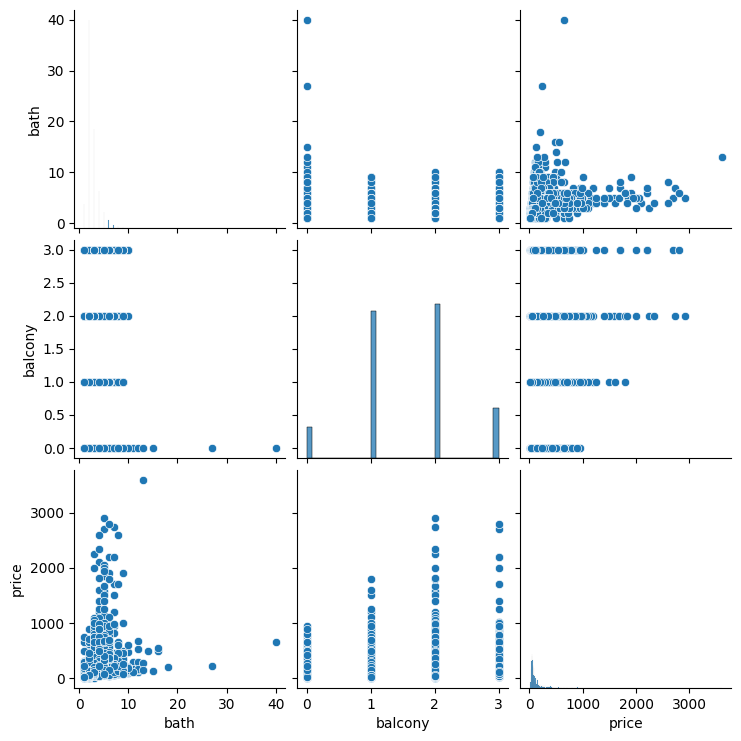

In [9]:
sns.pairplot(df)

<Axes: >

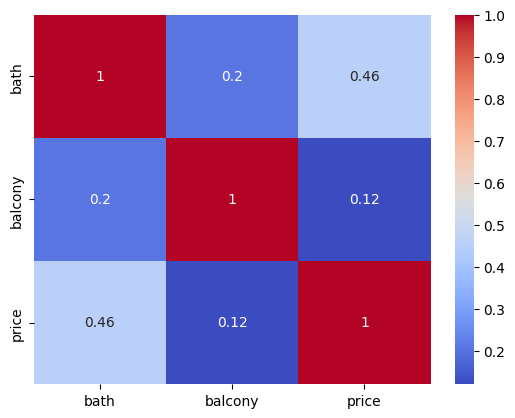

In [10]:
num_vars = ["bath", "balcony","price"]
sns.heatmap(df[num_vars].corr(), annot=True, cmap="coolwarm")

Tiển xử  lý dữ liệu

1. thống kê giá trị null của từng thuộc tính

In [11]:
df.isnull().mean() * 100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

2. loại đi trường society vì tỷ lệ null cao

In [12]:
df2 = df.drop('society', axis='columns')
df2.shape

(13320, 8)

In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   total_sqft    13320 non-null  object 
 5   bath          13247 non-null  float64
 6   balcony       12711 non-null  float64
 7   price         13320 non-null  float64
dtypes: float64(3), object(5)
memory usage: 832.6+ KB


3. thay thế giá trị null trong trương balcony bằng giá trị trung bình của các giá trị non-null

In [14]:
df2['balcony'] = df2['balcony'].fillna(df2['balcony'].mean())
df2.isnull().sum()

area_type        0
availability     0
location         1
size            16
total_sqft       0
bath            73
balcony          0
price            0
dtype: int64

In [15]:
# xóa đi các mau NaN
df3 = df2.dropna()
df3.shape

(13246, 8)

In [16]:
# Thong kê lại
df3.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

xử lí các trương mà có dữ liệu là string ...

In [17]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13246 non-null  object 
 1   availability  13246 non-null  object 
 2   location      13246 non-null  object 
 3   size          13246 non-null  object 
 4   total_sqft    13246 non-null  object 
 5   bath          13246 non-null  float64
 6   balcony       13246 non-null  float64
 7   price         13246 non-null  float64
dtypes: float64(3), object(5)
memory usage: 931.4+ KB


In [18]:
# trường total_sqft
df3['total_sqft'].value_counts()

total_sqft
1200     843
1100     221
1500     204
2400     195
600      180
        ... 
2383       1
4830       1
555        1
785        1
804.1      1
Name: count, Length: 2067, dtype: int64

In [19]:
total_sqft_float=[]
for str_val in df3['total_sqft']:
    try:
        # thử nếu chuyển được về float
        total_sqft_float.append(float(str_val))
    except:
        # nếu lỗi 
        try:
            temp = [] # tạo mảng tạm
            temp = str_val.split('-') # tách chuỗi tại dấu '-'
            total_sqft_float.append((float(temp[0]) + float(temp[1]))/2) # lấy trung bình 2 số
        except:
            total_sqft_float.append(np.nan) # Nếu là khác thì gán nà NaN missing value

df4 = df3.reset_index(drop=True) # reset lại index

In [20]:
# thêm trương total_sqft_float vào df4
df5 = df4.join(pd.DataFrame(total_sqft_float, columns=['total_sqft_float']))
df5.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0


In [21]:
df5 = df5.drop('total_sqft', axis='columns')
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13246 entries, 0 to 13245
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         13246 non-null  object 
 1   availability      13246 non-null  object 
 2   location          13246 non-null  object 
 3   size              13246 non-null  object 
 4   bath              13246 non-null  float64
 5   balcony           13246 non-null  float64
 6   price             13246 non-null  float64
 7   total_sqft_float  13200 non-null  float64
dtypes: float64(4), object(4)
memory usage: 828.0+ KB


In [22]:
df5_copy = df5.copy()

In [23]:
cols = list(df5_copy.columns.values)
print(cols) 

['area_type', 'availability', 'location', 'size', 'bath', 'balcony', 'price', 'total_sqft_float']


In [24]:
df5_copy[cols[0:4] + [cols[-1]] + cols[4:-1]].head()

,area_type,availability,location,size,total_sqft_float,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00


In [25]:
# xem lạicác giá trị null
df5_copy.isnull().sum()

area_type            0
availability         0
location             0
size                 0
bath                 0
balcony              0
price                0
total_sqft_float    46
dtype: int64

In [26]:
df6 = df5_copy.dropna()
df6.shape

(13200, 8)

In [27]:
# xem lai thông tin
df6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13245
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         13200 non-null  object 
 1   availability      13200 non-null  object 
 2   location          13200 non-null  object 
 3   size              13200 non-null  object 
 4   bath              13200 non-null  float64
 5   balcony           13200 non-null  float64
 6   price             13200 non-null  float64
 7   total_sqft_float  13200 non-null  float64
dtypes: float64(4), object(4)
memory usage: 928.1+ KB


2. làm việc với thuộc tính size

In [28]:
df6['size'].value_counts()

size
2 BHK         5192
3 BHK         4277
4 Bedroom      816
4 BHK          574
3 Bedroom      541
1 BHK          527
2 Bedroom      325
5 Bedroom      293
6 Bedroom      190
1 Bedroom      100
8 Bedroom       83
7 Bedroom       83
5 BHK           56
9 Bedroom       45
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            7
8 BHK            5
11 BHK           2
10 BHK           2
11 Bedroom       2
27 BHK           1
19 BHK           1
43 Bedroom       1
16 BHK           1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [29]:
# chuyển thuộc tính size về số

size_int = []
for str_val in df6['size']:
    temp = []
    temp = str_val.split(' ') # tách chuỗi tại dấu ' '
    try:
        size_int.append(int(temp[0])) # lấy số đầu tiên
    except:
        size_int.append(np.nan) # nếu lỗi thì gán là NaN missing value
        print("noise", str_val)

In [30]:
# dánh lại index
df6 = df6.reset_index(drop=True)

In [31]:
# thêm trương bhk
df7 = df6.join(pd.DataFrame(size_int, columns=['bhk']))
df7.shape

(13200, 9)

In [32]:
df7.tail()

,area_type,availability,location,size,bath,balcony,price,total_sqft_float,bhk
13195,Built-up Area,Ready To Move,Whitefield,5 Bedroom,4.0,0.000000,231.0,3453.0,5
13196,Super built-up Area,Ready To Move,Richards Town,4 BHK,5.0,1.584376,400.0,3600.0,4
13197,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,2.0,1.000000,60.0,1141.0,2
13198,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,4.0,1.000000,488.0,4689.0,4
13199,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,1.0,1.000000,17.0,550.0,1


Phát hiện ngoại lệ và loại bỏ

<Axes: xlabel='total_sqft_float'>

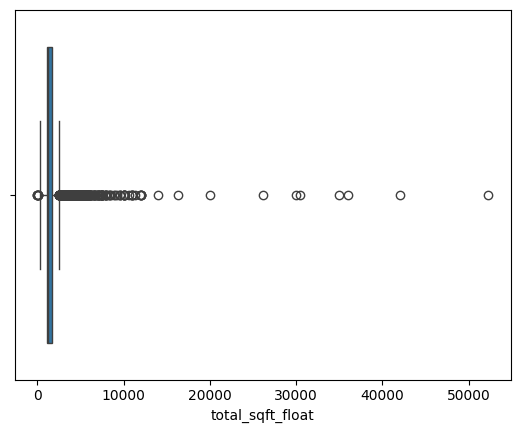

In [33]:
# xét trường tổng diện tích
sns.boxplot(x=df7['total_sqft_float'])

<Axes: xlabel='total_sqft_float'>

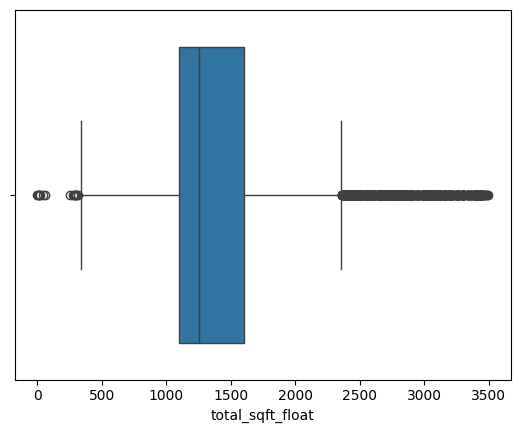

In [34]:
# chọn ngưỡng 3500 dể kt
df8 = df7[df7['total_sqft_float'] < 3500]
sns.boxplot(x=df8['total_sqft_float'])

In [35]:
Q1 = df8['total_sqft_float'].quantile(0.25)
Q3 = df8['total_sqft_float'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 337.5
Upper Bound: 2357.5


(10281, 9)

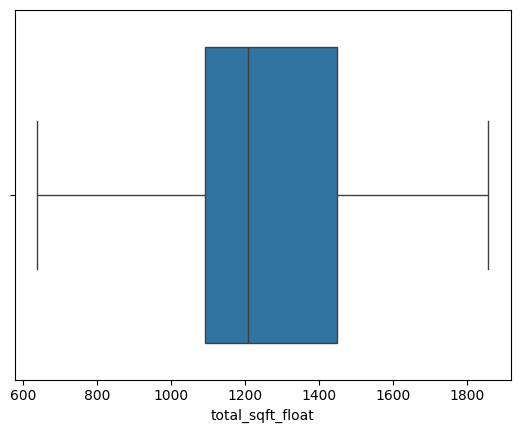

In [36]:
df9 = df8[(df8['total_sqft_float'] >= lower_bound + 300) & (df8['total_sqft_float'] <= upper_bound - 500)]
sns.boxplot(x=df9['total_sqft_float'])
df9.shape

In [37]:
# tạo thêm trường dữ liệu price_per_sqft(giá / diện tích feet vuông)
df9 = df9.reset_index(drop=True)
df9['price_per_sqft'] = df9['price'] * 100000 / df9['total_sqft_float']
df9.head()

,area_type,availability,location,size,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,2.0,1.0,39.07,1056.0,2,3699.810606
1,Built-up Area,Ready To Move,Uttarahalli,3 BHK,2.0,3.0,62.00,1440.0,3,4305.555556
2,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,3.0,1.0,95.00,1521.0,3,6245.890861
3,Super built-up Area,Ready To Move,Kothanur,2 BHK,2.0,1.0,51.00,1200.0,2,4250.000000
4,Super built-up Area,Ready To Move,Whitefield,2 BHK,2.0,1.0,38.00,1170.0,2,3247.863248


In [38]:
df9.price_per_sqft.describe()

count    10281.000000
mean      6046.302858
std       3551.565024
min       1166.666667
25%       4125.000000
50%       5110.132159
75%       6540.540541
max      76923.076923
Name: price_per_sqft, dtype: float64

# chuyển dữ liệu từ dạng category sang numeric cho các thuộc tính còn lại

In [39]:
df9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10281 entries, 0 to 10280
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         10281 non-null  object 
 1   availability      10281 non-null  object 
 2   location          10281 non-null  object 
 3   size              10281 non-null  object 
 4   bath              10281 non-null  float64
 5   balcony           10281 non-null  float64
 6   price             10281 non-null  float64
 7   total_sqft_float  10281 non-null  float64
 8   bhk               10281 non-null  int64  
 9   price_per_sqft    10281 non-null  float64
dtypes: float64(5), int64(1), object(4)
memory usage: 803.3+ KB


In [40]:
value_count(df9.iloc[:,:4]) # iloc[:,:4] lấy tất cả các dòng và 4 cột đầu tiên của df9 để đếm giá trị

area_type
Super built-up  Area    7269
Built-up  Area          1717
Plot  Area              1232
Carpet  Area              63


availability
Ready To Move    8162
18-May            237
18-Dec            228
18-Apr            223
18-Aug            178
19-Dec            129
18-Jul            117
18-Jun             84
18-Mar             83
20-Dec             81
21-Dec             68
19-Mar             67
18-Feb             48
18-Nov             40
18-Sep             39
19-Jul             34
18-Jan             32
18-Oct             29
19-Jan             26
20-Jan             24
19-Jun             21
17-Oct             20
17-Dec             20
22-Jun             19
19-Apr             16
21-Jun             13
19-Aug             12
17-Jun             12
19-Sep             12
20-Aug             12
21-Mar             11
17-Jul             11
22-Dec             10
21-Jan              9
17-Nov              9
20-Jun              9
17-Aug              8
17-Sep              8
21-May              8
2

In [41]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

In [42]:
# xử lí cho trường "area_type" --> dùng one-hot encoding
area_type_dummies = pd.get_dummies(df9['area_type'], prefix='area_type')
df10 = pd.concat([df9, area_type_dummies], axis=1)
df10.drop('area_type', axis='columns', inplace=True)

In [43]:
df10

,availability,location,size,bath,balcony,price,total_sqft_float,bhk,price_per_sqft,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,19-Dec,Electronic City Phase II,2 BHK,2.0,1.0,39.07,1056.0,2,3699.810606,False,False,False,True
1,Ready To Move,Uttarahalli,3 BHK,2.0,3.0,62.00,1440.0,3,4305.555556,True,False,False,False
2,Ready To Move,Lingadheeranahalli,3 BHK,3.0,1.0,95.00,1521.0,3,6245.890861,False,False,False,True
3,Ready To Move,Kothanur,2 BHK,2.0,1.0,51.00,1200.0,2,4250.000000,False,False,False,True
4,Ready To Move,Whitefield,2 BHK,2.0,1.0,38.00,1170.0,2,3247.863248,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10276,Ready To Move,Ramamurthy Nagar,7 Bedroom,9.0,2.0,250.00,1500.0,7,16666.666667,False,False,True,False
10277,Ready To Move,Bellandur,2 BHK,2.0,2.0,47.00,1262.0,2,3724.247227,False,False,False,True
10278,Ready To Move,Uttarahalli,3 BHK,2.0,1.0,57.00,1345.0,3,4237.918216,False,False,False,True
10279,Ready To Move,Green Glen Layout,3 BHK,3.0,3.0,112.00,1715.0,3,6530.612245,False,False,False,True


In [44]:
# xư lí cho trường availability
df10['is_ready'] = (df10['availability'] == 'Ready To Move').astype(int)
df10.drop('availability', axis='columns', inplace=True)

In [45]:
# xử ly cho trường location (thay bằng mean price của khu vực đó)
location_mean = df10.groupby('location')['price'].mean()
df10['location_encoded'] = df10['location'].map(location_mean)
df10.drop('location', axis='columns', inplace=True)

In [46]:
df8['bhk'] = df10['size'].str.split(' ').str[0].astype(int)
df10.drop("size", axis='columns', inplace=True)

/tmp/ipykernel_25396/1009257644.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df8['bhk'] = df10['size'].str.split(' ').str[0].astype(int)


In [47]:
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10281 entries, 0 to 10280
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   bath                            10281 non-null  float64
 1   balcony                         10281 non-null  float64
 2   price                           10281 non-null  float64
 3   total_sqft_float                10281 non-null  float64
 4   bhk                             10281 non-null  int64  
 5   price_per_sqft                  10281 non-null  float64
 6   area_type_Built-up  Area        10281 non-null  bool   
 7   area_type_Carpet  Area          10281 non-null  bool   
 8   area_type_Plot  Area            10281 non-null  bool   
 9   area_type_Super built-up  Area  10281 non-null  bool   
 10  is_ready                        10281 non-null  int64  
 11  location_encoded                10281 non-null  float64
dtypes: bool(4), float64(6), int64(2)

# Chuẩn hóa dữ liệu

In [48]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler()
new_data_1 = scaler.fit_transform(df10) 
standard = StandardScaler()
new_data_2 = standard.fit_transform(df10)

In [49]:
new_data_1

array([[0.05882353, 0.33333333, 0.04038163, ..., 1.        , 0.        ,
        0.07263683],
       [0.05882353, 1.        , 0.07279152, ..., 0.        , 1.        ,
        0.11029032],
       [0.11764706, 0.33333333, 0.11943463, ..., 1.        , 1.        ,
        0.23437653],
       ...,
       [0.05882353, 0.33333333, 0.06572438, ..., 1.        , 1.        ,
        0.11029032],
       [0.11764706, 1.        , 0.1434629 , ..., 1.        , 1.        ,
        0.22369792],
       [0.05882353, 0.33333333, 0.06996466, ..., 0.        , 1.        ,
        0.11240397]], shape=(10281, 12))

> Giảm chiều dữ liệu

In [51]:
# PCA (Principal Component Analysis)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(new_data_1)
print(X_pca.shape)

# SVD (Singular Value Decomposition)
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=4)
X_svd = svd.fit_transform(new_data_2)
print(X_svd.shape)

(10281, 2)
(10281, 4)


# Bài tập

> Bài tập 1

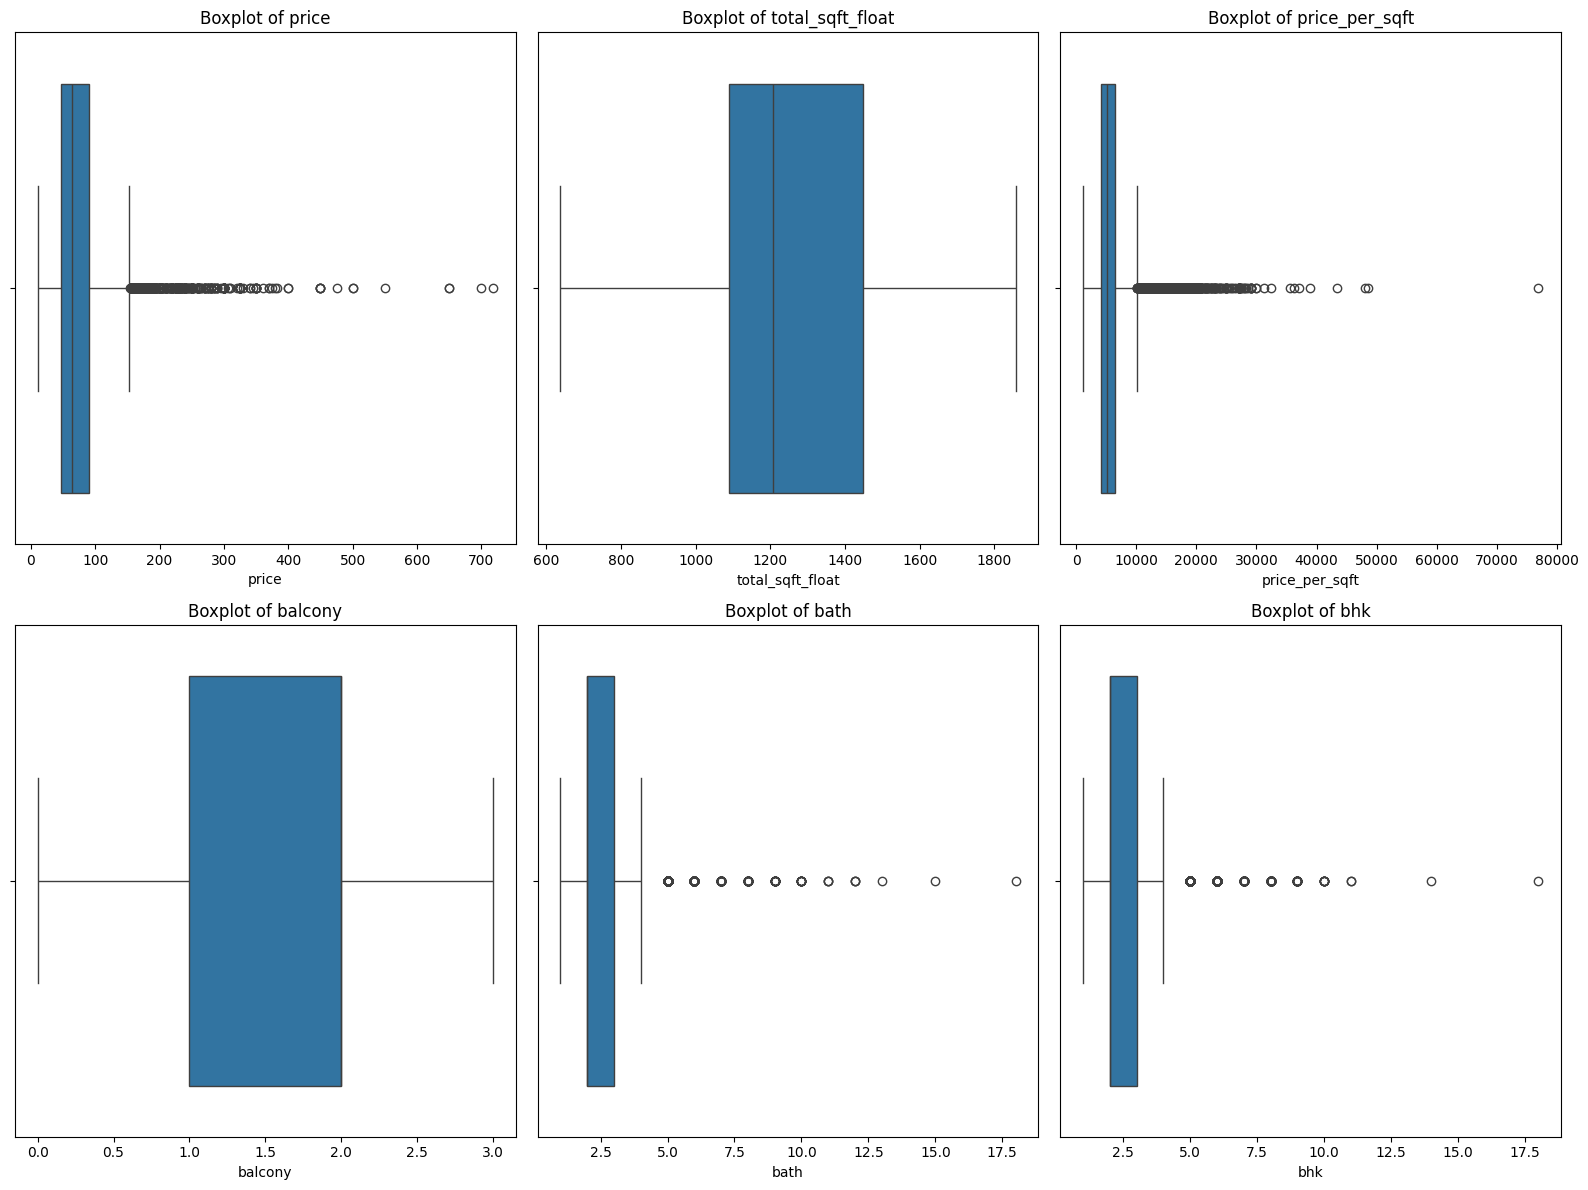

In [52]:
# Sử dụng boxplot để quan sát phân bố của dữ liệu, phát hiện ngoại lai (xử lí nếu cần) của từng trường dữ liệu trong vars
# Gợi ý: sns.boxplot(data_field)
vars = ['price', 'total_sqft_float', 'price_per_sqft', 'balcony', 'bath', 'bhk']
plt.figure(figsize=(16,12))

#Code ở đây
for i, var in enumerate(vars):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=df10[var])
    plt.title(f'Boxplot of {var}')
plt.tight_layout()
plt.show()

> Bài tập 2

In [54]:
df9

,area_type,availability,location,size,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,2.0,1.0,39.07,1056.0,2,3699.810606
1,Built-up Area,Ready To Move,Uttarahalli,3 BHK,2.0,3.0,62.00,1440.0,3,4305.555556
2,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,3.0,1.0,95.00,1521.0,3,6245.890861
3,Super built-up Area,Ready To Move,Kothanur,2 BHK,2.0,1.0,51.00,1200.0,2,4250.000000
4,Super built-up Area,Ready To Move,Whitefield,2 BHK,2.0,1.0,38.00,1170.0,2,3247.863248
...,...,...,...,...,...,...,...,...,...,...
10276,Plot Area,Ready To Move,Ramamurthy Nagar,7 Bedroom,9.0,2.0,250.00,1500.0,7,16666.666667
10277,Super built-up Area,Ready To Move,Bellandur,2 BHK,2.0,2.0,47.00,1262.0,2,3724.247227
10278,Super built-up Area,Ready To Move,Uttarahalli,3 BHK,2.0,1.0,57.00,1345.0,3,4237.918216
10279,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,3.0,3.0,112.00,1715.0,3,6530.612245


In [55]:
def remove_pps_outliers(df):
  #Code ở đây
  df_out = pd.DataFrame()
  for key, subdf in df.groupby('location'):
    mean = np.mean(subdf.price_per_sqft)
    std = np.std(subdf.price_per_sqft)

    filtered_subdf = subdf[(subdf.price_per_sqft >= (mean - std)) & (subdf.price_per_sqft <= (mean + std))]
    df_out = pd.concat([df_out, filtered_subdf], ignore_index=True)
  return df_out
    
#--------
df11 = remove_pps_outliers(df9)
df11.shape

(8246, 10)

> Bài tập 3